# Scenario API Smoke Test

This notebook tests the basic functionality of the scenario API.

## A. Imports

In [1]:
import sys
from pathlib import Path

# Locate the repository root by searching for extensions/scenario_api
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'extensions' / 'scenario_api').exists()), None)
if repo_root is None:
    raise RuntimeError('Could not locate extensions/scenario_api from current working directory')

extensions_dir = repo_root / 'extensions'
if str(extensions_dir) not in sys.path:
    sys.path.insert(0, str(extensions_dir))

from scenario_api import *


## B. Parameter Blocks

In [2]:
# Variant block
variant_block = create_block(
    name="variant",
    params={"relative_transmission": 1.3, "asymptomatic_fraction": 0.35}
)

# Testing block
testing_block = create_block(
    name="testing",
    params={"testing_rate": 0.2}
)

print("Blocks created:")
print(variant_block)
print(testing_block)

Blocks created:
ParameterBlock(name='variant', params={'relative_transmission': 1.3, 'asymptomatic_fraction': 0.35}, metadata={})
ParameterBlock(name='testing', params={'testing_rate': 0.2}, metadata={})


## C. Network Specifications

In [3]:
# Household network
household_spec = create_network_spec(
    name="household",
    kind="household",
    config={"size": 1000}
)

# Community network
community_spec = create_network_spec(
    name="community",
    kind="community",
    config={"size": 5000}
)

print("Network specs created:")
print(household_spec)
print(community_spec)

Network specs created:
NetworkSpec(name='household', kind='household', config={'size': 1000}, metadata={})
NetworkSpec(name='community', kind='community', config={'size': 5000}, metadata={})


## D. Timeline Events

In [4]:
# Event at step 10: set relative_transmission = 0.9
event1 = create_event(
    time=10,
    action="set",
    target="relative_transmission",
    value=0.9
)

# Event at step 20: scale testing_rate *= 1.5
event2 = create_event(
    time=20,
    action="scale",
    target="testing_rate",
    value=1.5
)

print("Events created:")
print(event1)
print(event2)

Events created:
TimelineEvent(time=10, action='set', target='relative_transmission', value=0.9, event_type='soft', metadata={})
TimelineEvent(time=20, action='scale', target='testing_rate', value=1.5, event_type='soft', metadata={})


## E. Scenario

In [5]:
# Create scenario
scenario = create_scenario(
    name="test_scenario",
    base_params={"population_size": 10000, "relative_transmission": 1.0, "testing_rate": 0.1},
    blocks=[variant_block, testing_block],
    network_specs=[household_spec, community_spec],
    events=[event1, event2]
)

print("Scenario created:")
print(scenario)

# Resolve scenario
resolved = resolve_scenario(scenario)
print("\nResolved scenario:")
print(resolved)

Scenario created:
Scenario(name='test_scenario', base_params={'population_size': 10000, 'relative_transmission': 1.0, 'testing_rate': 0.1}, blocks=[ParameterBlock(name='variant', params={'relative_transmission': 1.3, 'asymptomatic_fraction': 0.35}, metadata={}), ParameterBlock(name='testing', params={'testing_rate': 0.2}, metadata={})], network_specs=[NetworkSpec(name='household', kind='household', config={'size': 1000}, metadata={}), NetworkSpec(name='community', kind='community', config={'size': 5000}, metadata={})], events=[TimelineEvent(time=10, action='set', target='relative_transmission', value=0.9, event_type='soft', metadata={}), TimelineEvent(time=20, action='scale', target='testing_rate', value=1.5, event_type='soft', metadata={})], parent=None, metadata={})

Resolved scenario:
ResolvedScenario(name='test_scenario', resolved_params={'population_size': 10000, 'relative_transmission': 1.3, 'testing_rate': 0.2, 'asymptomatic_fraction': 0.35}, network_specs=[NetworkSpec(name='hou

## F. Dummy Runner

In [6]:
# Run the scenario
result = run_scenario(resolved, steps=30)
print("Simulation result:")
print(result)

Simulation result:
SimulationResult(scenario_name='test_scenario', raw_outputs={'cases': [0.26, 0.3380000000000001, 0.4394000000000001, 0.5712200000000002, 0.7425860000000003, 0.9653618000000004, 1.2549703400000007, 1.6314614420000009, 2.1208998746000014, 2.757169836980002, 2.481452853282002, 2.2333075679538017, 2.0099768111584218, 1.8089791300425795, 1.6280812170383214, 1.4652730953344895, 1.3187457858010405, 1.1868712072209364, 1.068184086498843, 0.9613656778489587, 1.2978436650960945, 1.168059298586485, 1.0512533687278365, 0.9461280318550529, 0.8515152286695477, 0.7663637058025929, 0.6897273352223338, 0.6207546017001004, 0.5586791415300905, 0.5028112273770814]}, metadata={'steps': 30, 'final_params': {'population_size': 10000, 'relative_transmission': 0.9, 'testing_rate': 0.30000000000000004, 'asymptomatic_fraction': 0.35}})


## G. Result to Time Series

Time series:
TimeSeries(name='test_scenario_cases', times=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], values=[0.26, 0.3380000000000001, 0.4394000000000001, 0.5712200000000002, 0.7425860000000003, 0.9653618000000004, 1.2549703400000007, 1.6314614420000009, 2.1208998746000014, 2.757169836980002, 2.481452853282002, 2.2333075679538017, 2.0099768111584218, 1.8089791300425795, 1.6280812170383214, 1.4652730953344895, 1.3187457858010405, 1.1868712072209364, 1.068184086498843, 0.9613656778489587, 1.2978436650960945, 1.168059298586485, 1.0512533687278365, 0.9461280318550529, 0.8515152286695477, 0.7663637058025929, 0.6897273352223338, 0.6207546017001004, 0.5586791415300905, 0.5028112273770814], variable='cases', source_type='simulation', source_name='test_scenario', metadata={})


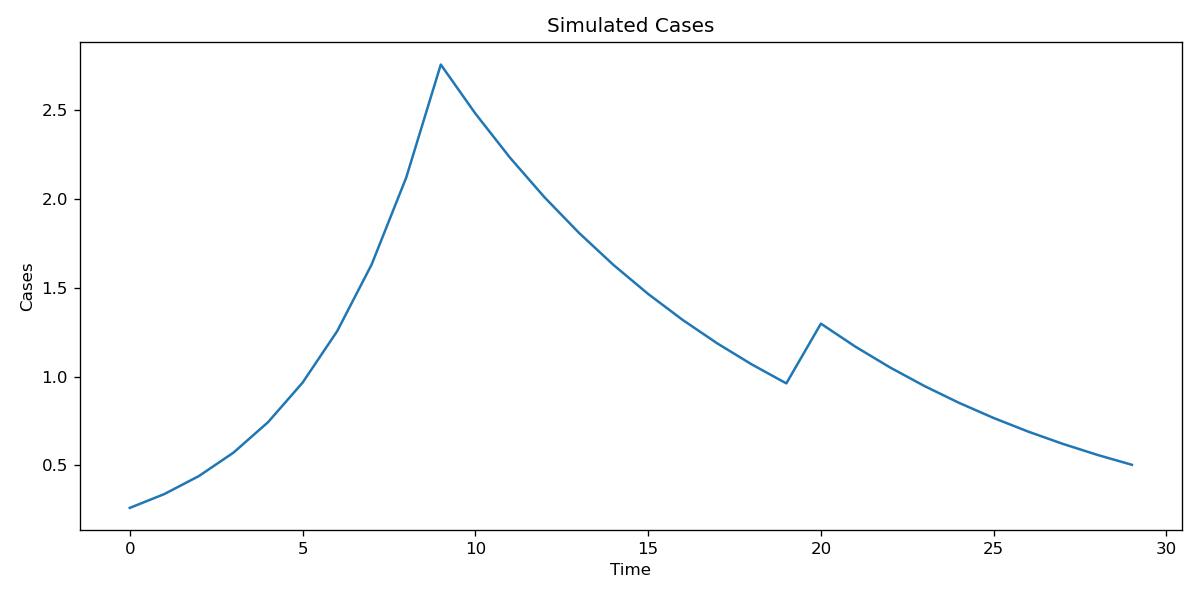

In [7]:
# Convert to time series
ts = result_to_timeseries(result, "cases")
print("Time series:")
print(ts)

# Render plot as PNG so it shows reliably in notebook outputs
import io
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts.times, ts.values)
ax.set_xlabel('Time')
ax.set_ylabel('Cases')
ax.set_title('Simulated Cases')
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120)
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))


## H. Observed Data

In [8]:
# Create observed data
observed_data = {
    "time": list(range(30)),
    "cases": [i * 0.5 + 1 for i in range(30)]
}

dataset = load_observed_dataset("test_data", observed_data)
obs_ts = dataset_to_timeseries(dataset, "cases")
print("Observed time series:")
print(obs_ts)

Observed time series:
TimeSeries(name='test_data_cases', times=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], values=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5], variable='cases', source_type='observed', source_name='test_data', metadata={})


## I. Comparison

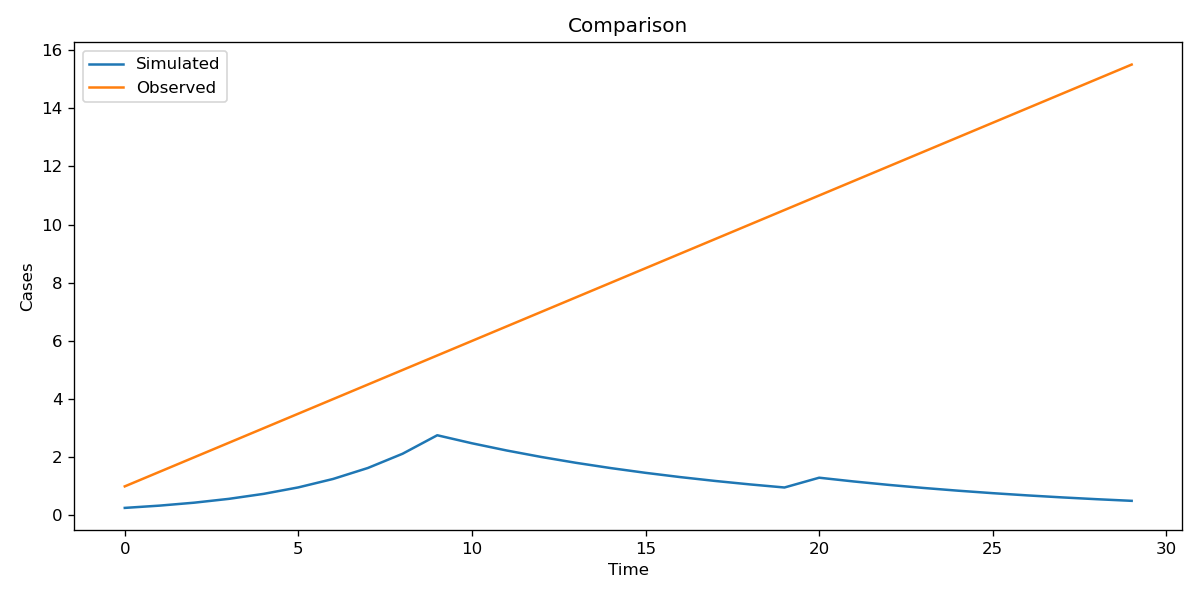

In [9]:
# Plot both
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts.times, ts.values, label='Simulated')
ax.plot(obs_ts.times, obs_ts.values, label='Observed')
ax.set_xlabel('Time')
ax.set_ylabel('Cases')
ax.set_title('Comparison')
ax.legend()
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120)
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))
